In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

print(os.getcwd())
print(os.listdir())

/Users/calvin/Desktop/FRA/CIA/data
['NIFTY 50.csv', '.DS_Store', 'CIA 2.ipynb', 'TCS.csv', 'HDFC.csv', '.ipynb_checkpoints', 'RELIANCE.csv']


In [3]:
hdfc = pd.read_csv('HDFC.csv')
tcs = pd.read_csv('TCS.csv')
reliance = pd.read_csv('RELIANCE.csv')
nifty = pd.read_csv('NIFTY 50.csv')

print("HDFC:", hdfc.shape)
print("TCS:", tcs.shape)
print("Reliance:", reliance.shape)
print("NIFTY:", nifty.shape)

HDFC: (60, 19)
TCS: (61, 2)
Reliance: (61, 9)
NIFTY: (60, 3)


In [4]:
print("HDFC columns:")
print(hdfc.columns.tolist())

print("\nTCS columns:")
print(tcs.columns.tolist())

print("\nReliance columns:")
print(reliance.columns.tolist())

print("\nNIFTY columns:")
print(nifty.columns.tolist())

HDFC columns:
['Month', 'Monthly Close', 'Monthly Return', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Month.1', 'Monthly Close.1', 'Monthly Return.1', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'RF', '6.00%']

TCS columns:
['Month', 'Monthly Close']

Reliance columns:
['Month', 'Reliance Monthly Close', 'Monthly Return', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Month.1', 'Reliance Monthly Close.1', 'Monthly Return.1']

NIFTY columns:
['Month', 'Reliance Monthly Close', 'Monthly Return']


In [10]:
# Re-load the original CSVs to start clean

hdfc = pd.read_csv('HDFC.csv')
tcs = pd.read_csv('TCS.csv')
reliance = pd.read_csv('RELIANCE.csv')
nifty = pd.read_csv('NIFTY 50.csv')

# Select only required columns
hdfc_clean = hdfc[['Month', 'Monthly Close']].copy()
tcs_clean = tcs[['Month', 'Monthly Close']].copy()
reliance_clean = reliance[['Month', 'Reliance Monthly Close']].copy()
nifty_clean = nifty[['Month', 'Reliance Monthly Close']].copy()

# Rename columns
hdfc_clean.columns = ['Month', 'HDFC']
tcs_clean.columns = ['Month', 'TCS']
reliance_clean.columns = ['Month', 'RELIANCE']
nifty_clean.columns = ['Month', 'NIFTY50']

# Standardize month names (April -> Apr)
def clean_month(x):
    x = str(x).strip()
    x = x.replace('April', 'Apr')
    x = x.replace('August', 'Aug')
    x = x.replace('September', 'Sep')
    x = x.replace('October', 'Oct')
    x = x.replace('November', 'Nov')
    x = x.replace('December', 'Dec')
    x = x.replace('January', 'Jan')
    x = x.replace('February', 'Feb')
    x = x.replace('March', 'Mar')
    x = x.replace('May', 'May')
    x = x.replace('June', 'Jun')
    x = x.replace('July', 'Jul')
    return x

# Convert Month correctly
for df in [hdfc_clean, tcs_clean, reliance_clean, nifty_clean]:
    df['Month'] = df['Month'].apply(clean_month)
    df['Month'] = pd.to_datetime(df['Month'], format='%b-%y')

# Convert prices to numeric
for df in [hdfc_clean, tcs_clean, reliance_clean, nifty_clean]:
    price_col = df.columns[1]
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

# Merge
prices = hdfc_clean.merge(tcs_clean, on='Month', how='inner')
prices = prices.merge(reliance_clean, on='Month', how='inner')
prices = prices.merge(nifty_clean, on='Month', how='inner')

# Sort
prices = prices.sort_values('Month').reset_index(drop=True)

print(prices.head())
print("\nShape:", prices.shape)
print("\nMissing values:")
print(prices.isna().sum())

       Month    HDFC  TCS  RELIANCE   NIFTY50
0 2021-01-01  695.25  NaN    920.98  13634.60
1 2021-02-01  767.20  NaN       NaN  14529.15
2 2021-03-01  746.83  NaN       NaN  14690.70
3 2021-04-01  706.15  NaN    997.25  14631.10
4 2021-05-01  757.93  NaN       NaN  15582.80

Shape: (60, 5)

Missing values:
Month        0
HDFC         0
TCS         60
RELIANCE    58
NIFTY50      0
dtype: int64


In [11]:
print("HDFC months:")
print(hdfc['Month'].head(10).tolist())

print("\nTCS months:")
print(tcs['Month'].head(10).tolist())

print("\nReliance months:")
print(reliance['Month'].head(10).tolist())

print("\nNIFTY months:")
print(nifty['Month'].head(10).tolist())

HDFC months:
['Jan-21', 'Feb-21', 'Mar-21', 'Apr-21', 'May-21', 'Jun-21', 'Jul-21', 'Aug-21', 'Sep-21', 'Oct-21']

TCS months:
['Dec-20', 'Jan-21', 'Feb-21', 'Mar-21', 'Apr-21', 'May-21', 'Jun-21', 'Jul-21', 'Aug-21', 'Sep-21']

Reliance months:
['Dec-20', 'Jan-21', 'Feb-21', 'Mar-21', 'April-21', 'May-21', 'Jun-21', 'Jul-21', 'Aug-21', 'Sep-21']

NIFTY months:
['Jan-21', 'Feb-21', 'Mar-21', 'Apr-21', 'May-21', 'Jun-21', 'Jul-21', 'Aug-21', 'Sep-21', 'Oct-21']


In [12]:
import pandas as pd

def clean_month(series):
    return pd.to_datetime(
        series.astype(str)
        .str.replace("April", "Apr", regex=False)
        .str.strip(),
        format="%b-%y"
    )

# Clean month columns
hdfc['Month'] = clean_month(hdfc['Month'])
tcs['Month'] = clean_month(tcs['Month'])
reliance['Month'] = clean_month(reliance['Month'])
nifty['Month'] = clean_month(nifty['Month'])

# Keep only the columns we need
hdfc_clean = hdfc[['Month', 'Monthly Close']].rename(columns={'Monthly Close': 'HDFC'})
tcs_clean = tcs[['Month', 'Monthly Close']].rename(columns={'Monthly Close': 'TCS'})
reliance_clean = reliance[['Month', 'Reliance Monthly Close']].rename(columns={'Reliance Monthly Close': 'RELIANCE'})
nifty_clean = nifty[['Month', 'Reliance Monthly Close']].rename(columns={'Reliance Monthly Close': 'NIFTY50'})

# Merge everything by Month
data = hdfc_clean.merge(tcs_clean, on='Month', how='inner')
data = data.merge(reliance_clean, on='Month', how='inner')
data = data.merge(nifty_clean, on='Month', how='inner')

# Keep assignment period: Jan-2021 to Dec-2025
data = data[(data['Month'] >= '2021-01-01') & (data['Month'] <= '2025-12-01')]

data = data.sort_values('Month').reset_index(drop=True)

print(data.head())
print("\nShape:", data.shape)
print("\nMissing values:")
print(data.isna().sum())

       Month    HDFC       TCS  RELIANCE   NIFTY50
0 2021-01-01  695.25  3,111.35    920.98  13634.60
1 2021-02-01  767.20  2,894.30  1,042.90  14529.15
2 2021-03-01  746.83  3,177.85  1,001.55  14690.70
3 2021-04-01  706.15  3,035.65    997.25  14631.10
4 2021-05-01  757.93  3,159.15  1,080.15  15582.80

Shape: (60, 5)

Missing values:
Month       0
HDFC        0
TCS         0
RELIANCE    0
NIFTY50     0
dtype: int64


In [14]:
# Convert stock/index prices from text to numbers
price_columns = ['HDFC', 'TCS', 'RELIANCE', 'NIFTY50']

for col in price_columns:
    data[col] = (
        data[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

# Calculate monthly returns
for col in price_columns:
    data[col + '_Return'] = data[col].pct_change()

# Remove January 2021 because it has no previous month
returns = data.dropna().copy()

print(returns.head())
print("\nShape:", returns.shape)
print("\nData types:")
print(data[price_columns].dtypes)

       Month    HDFC      TCS  RELIANCE   NIFTY50  HDFC_Return  TCS_Return  \
1 2021-02-01  767.20  2894.30   1042.90  14529.15     0.103488   -0.069761   
2 2021-03-01  746.83  3177.85   1001.55  14690.70    -0.026551    0.097968   
3 2021-04-01  706.15  3035.65    997.25  14631.10    -0.054470   -0.044747   
4 2021-05-01  757.93  3159.15   1080.15  15582.80     0.073327    0.040683   
5 2021-06-01  748.95  3345.75   1055.33  15721.50    -0.011848    0.059067   

   RELIANCE_Return  NIFTY50_Return  
1         0.132381        0.065609  
2        -0.039649        0.011119  
3        -0.004293       -0.004057  
4         0.083129        0.065046  
5        -0.022978        0.008901  

Shape: (59, 9)

Data types:
HDFC        float64
TCS         float64
RELIANCE    float64
NIFTY50     float64
dtype: object


In [15]:
import numpy as np

stocks = ['HDFC', 'TCS', 'RELIANCE']

# Risk-free rate
rf = 0.06

# NIFTY 50 annualized return
market_avg_monthly = returns['NIFTY50_Return'].mean()
market_annual_return = (1 + market_avg_monthly) ** 12 - 1

results = []

for stock in stocks:
    stock_return = returns[stock + '_Return']
    market_return = returns['NIFTY50_Return']
    
    # Average monthly return
    avg_monthly = stock_return.mean()
    
    # Annualized return
    annualized_return = (1 + avg_monthly) ** 12 - 1
    
    # Annualized standard deviation
    annualized_std = stock_return.std() * np.sqrt(12)
    
    # Beta
    beta = stock_return.cov(market_return) / market_return.var()
    
    # Correlation
    correlation = stock_return.corr(market_return)
    
    # CAPM required return
    capm_required = rf + beta * (market_annual_return - rf)
    
    # Sharpe Ratio
    sharpe = (annualized_return - rf) / annualized_std
    
    # Treynor Ratio
    treynor = (annualized_return - rf) / beta
    
    results.append([
        stock,
        avg_monthly,
        annualized_return,
        annualized_std,
        beta,
        correlation,
        capm_required,
        sharpe,
        treynor
    ])

results_df = pd.DataFrame(results, columns=[
    'Stock',
    'Average Monthly Return',
    'Annualized Return',
    'Annualized Risk',
    'Beta',
    'Correlation',
    'CAPM Required Return',
    'Sharpe Ratio',
    'Treynor Ratio'
])

print("NIFTY 50 Annualized Return:", round(market_annual_return * 100, 2), "%")
print()
print(results_df.round(4))

NIFTY 50 Annualized Return: 15.0 %

      Stock  Average Monthly Return  Annualized Return  Annualized Risk  \
0      HDFC                  0.0072             0.0901           0.1697   
1       TCS                  0.0024             0.0287           0.2118   
2  RELIANCE                  0.0106             0.1349           0.2019   

     Beta  Correlation  CAPM Required Return  Sharpe Ratio  Treynor Ratio  
0  0.8939       0.6552                0.1404        0.1775         0.0337  
1  0.8161       0.4794                0.1334       -0.1479        -0.0384  
2  1.1548       0.7114                0.1639        0.3711         0.0649  


In [22]:
# NIFTY 50 benchmark summary

benchmark_summary = pd.DataFrame({
    'Asset': ['HDFC Bank', 'TCS', 'Reliance', 'NIFTY 50'],
    'Annualized Return': [
        results_df.loc[0, 'Annualized Return'],
        results_df.loc[1, 'Annualized Return'],
        results_df.loc[2, 'Annualized Return'],
        market_annual_return
    ],
    'Annualized Risk': [
        results_df.loc[0, 'Annualized Risk'],
        results_df.loc[1, 'Annualized Risk'],
        results_df.loc[2, 'Annualized Risk'],
        returns['NIFTY50_Return'].std() * np.sqrt(12)
    ],
    'Beta': [
        results_df.loc[0, 'Beta'],
        results_df.loc[1, 'Beta'],
        results_df.loc[2, 'Beta'],
        1.00
    ]
})

print(benchmark_summary.round(4))

       Asset  Annualized Return  Annualized Risk    Beta
0  HDFC Bank             0.0901           0.1697  0.8939
1        TCS             0.0287           0.2118  0.8161
2   Reliance             0.1349           0.2019  1.1548
3   NIFTY 50             0.1500           0.1244  1.0000


In [16]:
# Portfolio weights
weights_A = {
    'HDFC': 1/3,
    'TCS': 1/3,
    'RELIANCE': 1/3
}

weights_B = {
    'HDFC': 0.40,
    'TCS': 0.10,
    'RELIANCE': 0.50
}

# Create portfolio monthly returns
portfolio_A = (
    returns['HDFC_Return'] * weights_A['HDFC'] +
    returns['TCS_Return'] * weights_A['TCS'] +
    returns['RELIANCE_Return'] * weights_A['RELIANCE']
)

portfolio_B = (
    returns['HDFC_Return'] * weights_B['HDFC'] +
    returns['TCS_Return'] * weights_B['TCS'] +
    returns['RELIANCE_Return'] * weights_B['RELIANCE']
)

# Function to calculate portfolio metrics
def portfolio_metrics(portfolio_return):
    
    avg_monthly = portfolio_return.mean()
    annual_return = (1 + avg_monthly) ** 12 - 1
    annual_risk = portfolio_return.std() * np.sqrt(12)
    
    beta = portfolio_return.cov(returns['NIFTY50_Return']) / returns['NIFTY50_Return'].var()
    
    sharpe = (annual_return - rf) / annual_risk
    
    return annual_return, annual_risk, beta, sharpe

# Calculate metrics
A_return, A_risk, A_beta, A_sharpe = portfolio_metrics(portfolio_A)
B_return, B_risk, B_beta, B_sharpe = portfolio_metrics(portfolio_B)

portfolio_results = pd.DataFrame({
    'Portfolio': ['Portfolio A - Equal Weight', 'Portfolio B - Analysis Based'],
    'Expected Return': [A_return, B_return],
    'Risk': [A_risk, B_risk],
    'Beta': [A_beta, B_beta],
    'Sharpe Ratio': [A_sharpe, B_sharpe]
})

print(portfolio_results.round(4))

                      Portfolio  Expected Return    Risk    Beta  Sharpe Ratio
0    Portfolio A - Equal Weight           0.0838  0.1466  0.9550        0.1622
1  Portfolio B - Analysis Based           0.1059  0.1533  1.0166        0.2995


In [17]:
# ₹10 lakh investment allocation

investment = 1000000

allocation = pd.DataFrame({
    'Stock': ['HDFC Bank', 'TCS', 'Reliance'],
    'Weight': [0.40, 0.10, 0.50]
})

allocation['Investment (₹)'] = allocation['Weight'] * investment

print(allocation)

       Stock  Weight  Investment (₹)
0  HDFC Bank     0.4        400000.0
1        TCS     0.1        100000.0
2   Reliance     0.5        500000.0


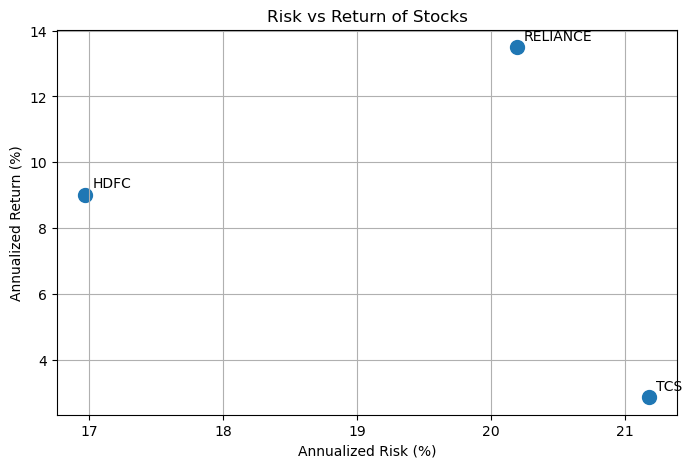

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    results_df['Annualized Risk'] * 100,
    results_df['Annualized Return'] * 100,
    s=100
)

for i, stock in enumerate(results_df['Stock']):
    plt.annotate(
        stock,
        (
            results_df['Annualized Risk'].iloc[i] * 100,
            results_df['Annualized Return'].iloc[i] * 100
        ),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Annualized Risk (%)')
plt.ylabel('Annualized Return (%)')
plt.title('Risk vs Return of Stocks')
plt.grid(True)
plt.show()

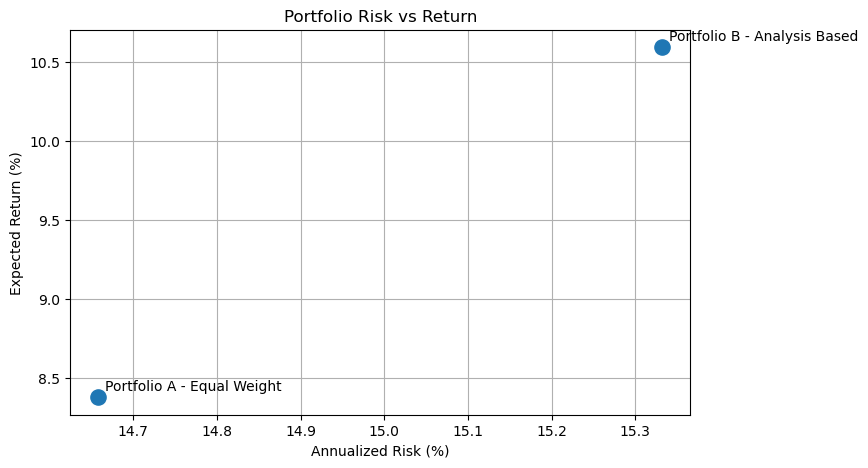

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    portfolio_results['Risk'] * 100,
    portfolio_results['Expected Return'] * 100,
    s=120
)

for i, portfolio in enumerate(portfolio_results['Portfolio']):
    plt.annotate(
        portfolio,
        (
            portfolio_results['Risk'].iloc[i] * 100,
            portfolio_results['Expected Return'].iloc[i] * 100
        ),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Annualized Risk (%)')
plt.ylabel('Expected Return (%)')
plt.title('Portfolio Risk vs Return')
plt.grid(True)
plt.show()

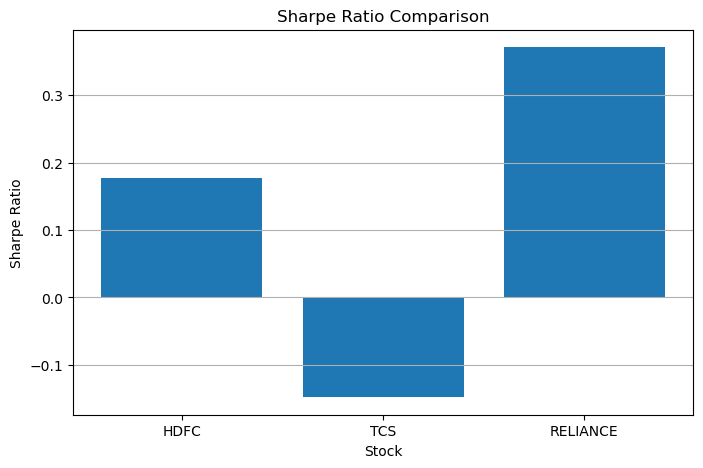

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df['Stock'],
    results_df['Sharpe Ratio']
)

plt.xlabel('Stock')
plt.ylabel('Sharpe Ratio')
plt.title('Sharpe Ratio Comparison')
plt.grid(axis='y')
plt.show()

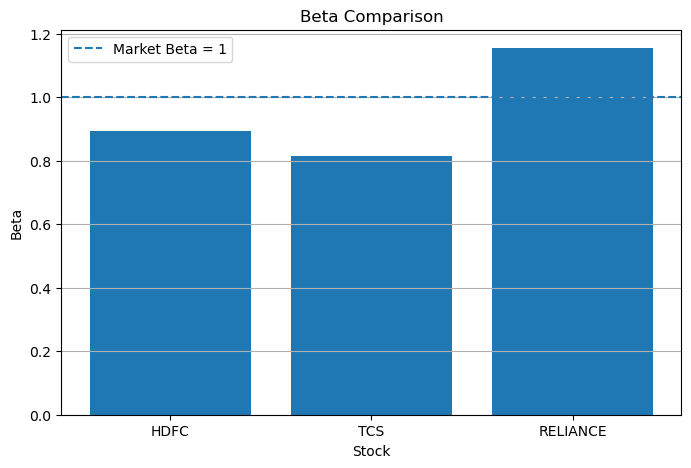

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df['Stock'],
    results_df['Beta']
)

plt.axhline(
    y=1,
    linestyle='--',
    label='Market Beta = 1'
)

plt.xlabel('Stock')
plt.ylabel('Beta')
plt.title('Beta Comparison')
plt.legend()
plt.grid(axis='y')
plt.show()